<a href="https://colab.research.google.com/github/hitarthmehtaa/Quant_learning_journey-/blob/main/Week1_Mini_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Adding the stock data from yahoo finance


In [ ]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd

Adding 4 companies here initially
  1) Apple
  2) Tesla
  3) Reliance
  4) TCS


In [ ]:
company = ['AAPL','TSLA','NVDA']

all_data = {}

for i in range(len(company)):
  ticker = yf.Ticker(company[i])
  historical_data = ticker.history(period='1y')
  historical_data['Volume(in cr)'] = historical_data['Volume']/1000000
  print(company[i],'s Stock Data over 1 Year')
  all_data[company[i]] = historical_data
  print(historical_data[['Open','High','Low','Close','Volume(in cr)']])


AAPL s Stock Data over 1 Year
                                 Open        High         Low       Close  \
Date                                                                        
2025-06-03 00:00:00-04:00  200.554355  202.964791  200.165897  202.466766   
2025-06-04 00:00:00-04:00  202.108195  205.425039  201.301399  202.018555   
2025-06-05 00:00:00-04:00  202.695858  203.940919  199.359090  199.837204   
2025-06-06 00:00:00-04:00  202.197834  204.887162  201.251591  203.114197   
2025-06-09 00:00:00-04:00  203.582346  205.185985  199.229619  200.653961   
...                               ...         ...         ...         ...   
2026-05-27 00:00:00-04:00  308.329987  313.260010  308.299988  310.850006   
2026-05-28 00:00:00-04:00  310.679993  312.799988  309.570007  312.510010   
2026-05-29 00:00:00-04:00  311.779999  315.000000  309.529999  312.059998   
2026-06-01 00:00:00-04:00  309.630005  310.940002  305.019989  306.309998   
2026-06-02 00:00:00-04:00  307.459991  315.450

Plotting the close values for apple

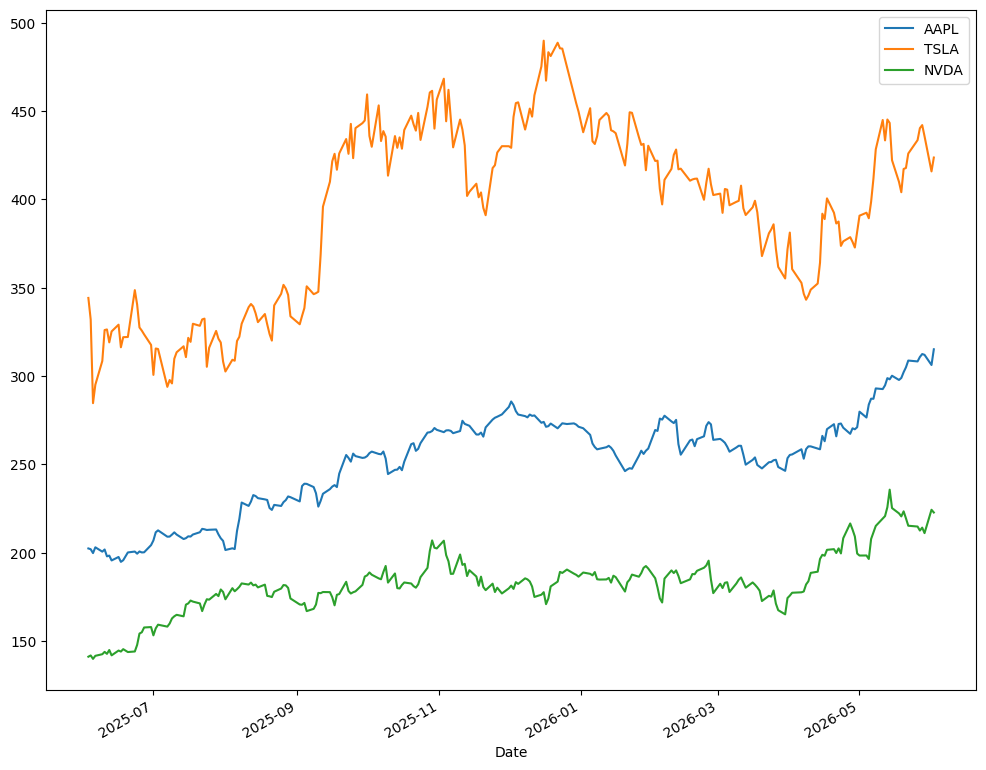

In [ ]:
df = pd.DataFrame()

for i in range(len(company)):
  df[company[i]] = all_data[company[i]]['Close']

df.plot(figsize=(12,10))
plt.show()

Daily Return Formulae = (P_t - P_t-1)/ P_t-1

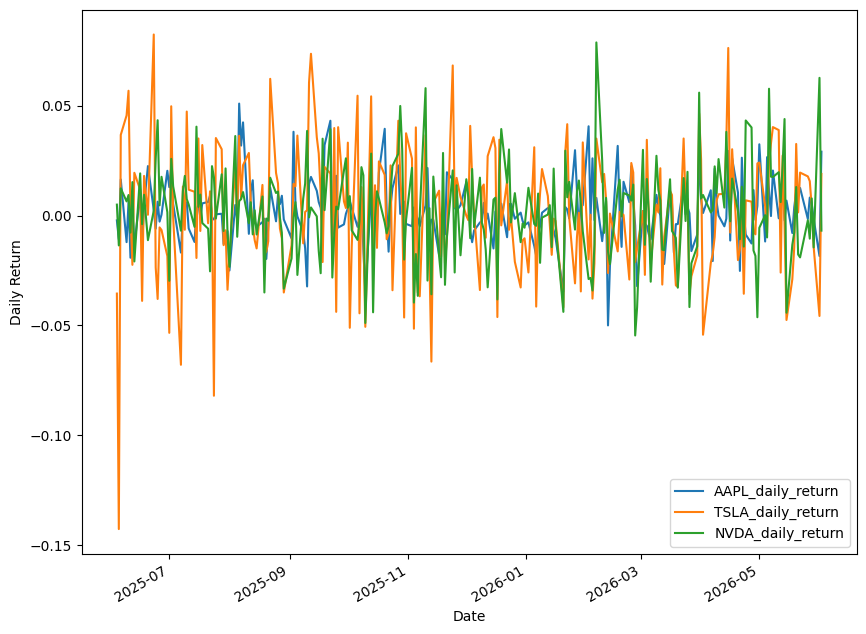

In [ ]:
for i in range (len(company)):
  df[f'{company[i]}_daily_return'] =  all_data[company[i]]['Close'].pct_change()

df[['AAPL_daily_return','TSLA_daily_return','NVDA_daily_return']].plot(figsize=(10,8))
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.show()



Moving Average


<Axes: xlabel='Date'>

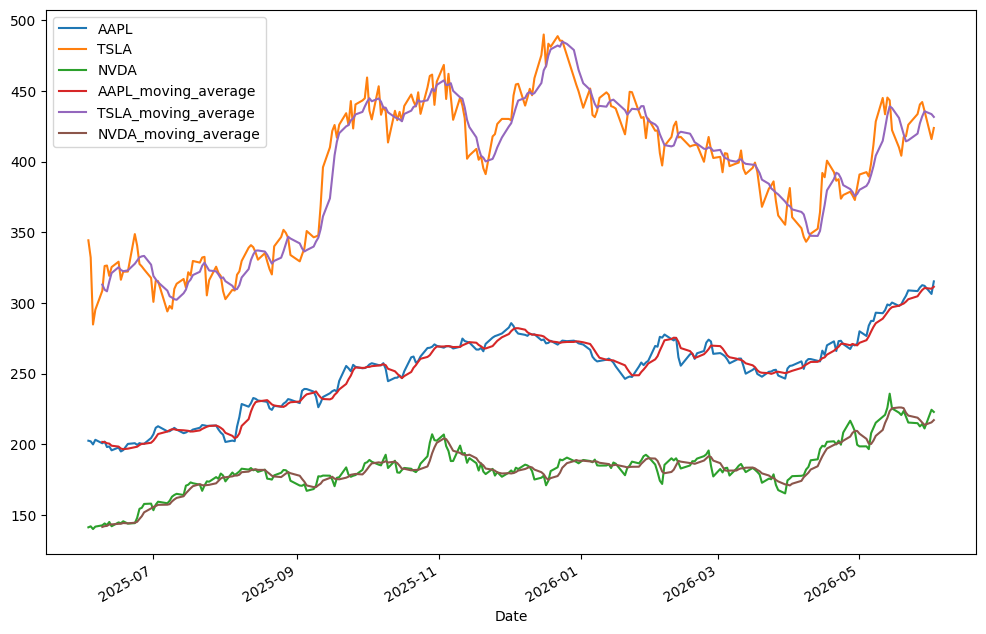

In [ ]:
for i in range(len(company)):
  df[f"{company[i]}_moving_average"] = df[company[i]].rolling(window=5).mean()

df[['AAPL','TSLA','NVDA','AAPL_moving_average','TSLA_moving_average','NVDA_moving_average']].plot(figsize=(12,8))




Volatility

<Axes: xlabel='Date'>

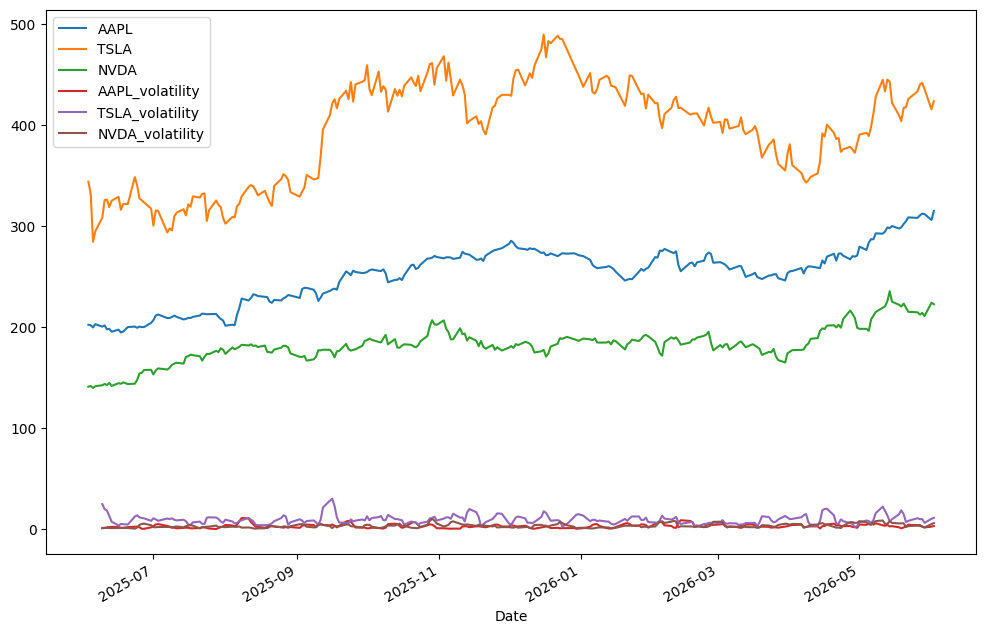

In [ ]:
for i in range(len(company)):
  df[f"{company[i]}_volatility"] = df[company[i]].rolling(window=5).std()

df[['AAPL','TSLA','NVDA','AAPL_volatility','TSLA_volatility','NVDA_volatility']].plot(figsize=(12,8))



In [ ]:
print(df['AAPL_volatility'].mean())
print(df['TSLA_volatility'].mean())
print(df['NVDA_volatility'].mean())

3.135239681993854
9.56408475872168
3.476472148267717


AS WE CAN SEE THAT TESLA HAS THE HIGHEST VOLATILITY FOLLOWED BY NVIDIA AND THE LAST IS APPLE WITH THE LOWEST OUT OF THE 3. THIS SHOWS THAT APPLE IS A SAFER STOCK TO INVEST IN RIGHT NOW FOR INVESTORS LOOKING FOR LOW VOLATILE OPTIONS.

NOW SHALL LOOK INTO CUMPROD

In [ ]:
apple_cumulative_returns = (1+df['AAPL_daily_return']).cumprod()
tesla_cumulative_returns = (1+df['TSLA_daily_return']).cumprod()
nvidia_cumulative_returns = (1+df['NVDA_daily_return']).cumprod()

print(apple_cumulative_returns[-1])
print(tesla_cumulative_returns[-1])
print(nvidia_cumulative_returns[-1])

1.556798766917616
1.2308362731482467
1.5781937882025714


/tmp/ipykernel_904/2552868024.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(apple_cumulative_returns[-1])
/tmp/ipykernel_904/2552868024.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(tesla_cumulative_returns[-1])
/tmp/ipykernel_904/2552868024.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(nvidia_cumulative_returns[-1])


In [ ]:
summary = pd.DataFrame ({
    'Company':['Apple','Tesla','Nvidia'],
    'Average Daily Return':[df['AAPL_daily_return'].mean(),df['TSLA_daily_return'].mean(),df['NVDA_daily_return'].mean()],
    'Volatility':[df['AAPL_volatility'].mean(),df['TSLA_volatility'].mean(),df['NVDA_volatility'].mean()],
    'Cumulative Returns':[apple_cumulative_returns[-1],tesla_cumulative_returns[-1],nvidia_cumulative_returns[-1]]
})

/tmp/ipykernel_904/3687648386.py:5: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  'Cumulative Returns':[apple_cumulative_returns[-1],tesla_cumulative_returns[-1],nvidia_cumulative_returns[-1]]


In [ ]:
summary

,Company,Average Daily Return,Volatility,Cumulative Returns
0,Apple,0.001870,3.135240,1.556799
1,Tesla,0.001263,9.564085,1.230836
2,Nvidia,0.002055,3.476472,1.578194


NOW WE SHALL MOVE ON FROM INDIVIDUAL STOCK ANALYSIS TO START TO MAKE A PORTFOLIO WITH THESE 3 STOCKS AND SEE THE PERFORMANCE.

In [27]:
returns = pd.DataFrame ()

returns['APPLE'] = df['AAPL_daily_return']
returns['TESLA'] = df['TSLA_daily_return']
returns['NVDA'] = df['NVDA_daily_return']

returns = returns.dropna()

In [28]:
returns

,APPLE,TESLA,NVDA
Date,,,
2025-06-04 00:00:00-04:00,-0.002214,-0.035495,0.004957
2025-06-05 00:00:00-04:00,-0.010798,-0.142599,-0.013599
2025-06-06 00:00:00-04:00,0.016398,0.036670,0.012358
2025-06-09 00:00:00-04:00,-0.012113,0.045538,0.006421
2025-06-10 00:00:00-04:00,0.006056,0.056744,0.009325
...,...,...,...
2026-05-27 00:00:00-04:00,0.008173,0.015614,-0.010518
2026-05-28 00:00:00-04:00,0.005340,0.003951,0.007761
2026-05-29 00:00:00-04:00,-0.001440,-0.014273,-0.014516


In [29]:
correlation = returns.corr()
print(correlation)

          APPLE     TESLA      NVDA
APPLE  1.000000  0.287942  0.186966
TESLA  0.287942  1.000000  0.327809
NVDA   0.186966  0.327809  1.000000


SINCE THE CORRELATION IS LOW, DEVELOPING A PORTFOLIO WILL BE BETTER FOR US.

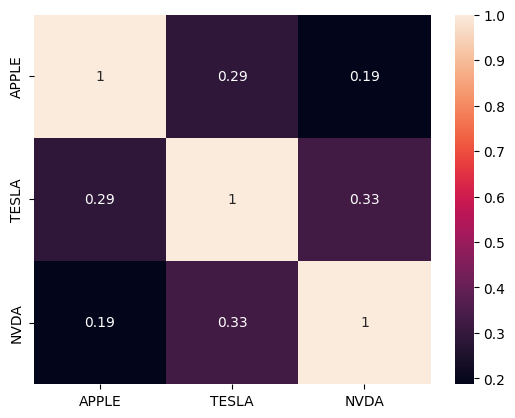

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(correlation,annot=True)
plt.show()

SO APPLE HAS A MID CORRELATION WITH TESLA AT 0.29 WHILE HAS A LOW CORRELATION WITH NVIDIA STOCK AT 0.19. LASTLY TESLA HAS THE HIGHEST CORRELATION WITH NVIDIA AT 0.33.

NOW MOVING ON WITH BUILDING AN ELEMENTARY PORTFOLIO WITH THESE 3 STOCKS.
FURTHER PORTFOLIO ANALYSIS SHALL BE CONDUCTED LIKE CALCULATING THE SHARPE RATIO, VOLATILITY ETC.

In [31]:
weights = [0.33,0.33,0.33]

portfolio_returns = (
    weights[0]*df['AAPL_daily_return']+ weights[1]*df['TSLA_daily_return']+ weights[2]*df['NVDA_daily_return']
)

In [33]:
portfolio_returns_volatility = portfolio_returns.std()

print(portfolio_returns_volatility)

0.01575660750395318


SO AS WE CAN SEE, WE HAVE ACHIEVED TO GET THE VOLATILITY DOWN INSTEAD OF HOLDING ONE WHICH WOULD HAVE BEEN ABOVE 1.

In [34]:
portfolio_returns

,0
Date,
2025-06-03 00:00:00-04:00,NaN
2025-06-04 00:00:00-04:00,-0.010808
2025-06-05 00:00:00-04:00,-0.055109
2025-06-06 00:00:00-04:00,0.021591
2025-06-09 00:00:00-04:00,0.013149
...,...
2026-05-27 00:00:00-04:00,0.004379
2026-05-28 00:00:00-04:00,0.005627
2026-05-29 00:00:00-04:00,-0.009975


WE SHALL BE USING THE PORTFOLIO RISK FORMULAE WHICH IS

$$
\sigma_p = \sqrt{w^T \Sigma w}
$$

1.4869793773677182


/tmp/ipykernel_904/4293091100.py:3: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(portfolio_cumulative[-1])


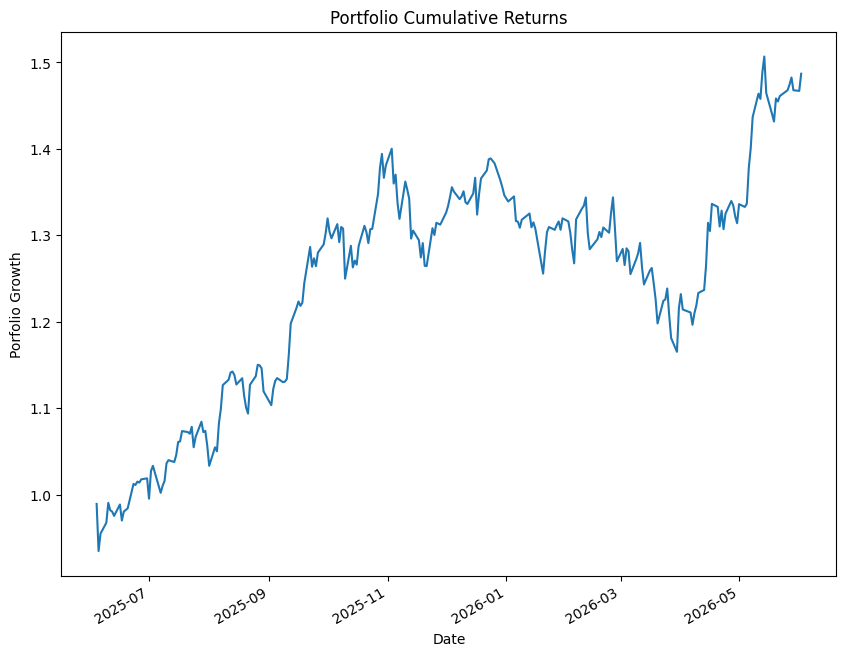

In [39]:
portfolio_cumulative = (1 + portfolio_returns).cumprod()

print(portfolio_cumulative[-1])
portfolio_cumulative.plot(figsize=(10,8))
plt.title('Portfolio Cumulative Returns')
plt.xlabel('Date')
plt.ylabel('Porfolio Growth')
plt.show()

THIS SHOWS THAT THE PORTFOLIO STILL PERFORMED RELATIVELY STRONG COMPARED TO INDIVIDUAL STOCKS. THIS ALSO SHOWS INVESTING IN A PORTFOLIO LIKE THIS HELPS US TO MANAGE RISK AND GET GOOD RETURNS.

SHARPE RATIO

$$
R_p-R_f/σ_p
$$

In [38]:
sharpe_ratio = portfolio_returns.mean()/ portfolio_returns_volatility
print(sharpe_ratio)

0.10865512583426346


SHARPE RATIO SHOWS POSITIVE RETURNS ACCOUNTING FOR THE RATE OF RISK. EVEN THOUGH TAKEN AS 0, WE SAW POSTIVE RETURNS.

* **CONCLUSION**

* **The equal-weight portfolio demonstrated moderate volatility with positive cumulative growth over the analyzed period. Diversification across Apple, Tesla, and Nvidia reduced overall portfolio risk relative to highly volatile individual equities. The positive Sharpe Ratio indicated favorable risk-adjusted performance.**